# 📊 TemporalAML: Exploratory Data Analysis (EDA)
### Elliptic Bitcoin Transaction Dataset

This notebook performs comprehensive exploratory data analysis on the raw Elliptic Bitcoin dataset in support of temporal-GNN AML modeling:
1. **Load Raw Data**: Loads features, class labels, and transaction edgelist using `pandas`.
2. **Verify Dataset Scale**: Confirms node count (203,769), edge count (234,355), and temporal span (49 time steps).
3. **Class Distribution**: Quantifies the balance between Licit (`2`), Illicit (`1`), and Unlabeled (`unknown`) transactions.
4. **Visualizations**:
   - Node volume per time step (stratified by class)
   - Illicit transaction ratio across time steps
   - In-degree and out-degree distributions on a log-log scale
5. **Referential Integrity**: Checks whether any transaction ID (`txId`) in the edgelist is missing from the features file.
6. **Executive Summary**: Synthesizes key findings and architectural implications for temporal-GNN training.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from IPython.display import display

# Set plotting aesthetics
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

print("Environment configured successfully. Ready to analyze Elliptic dataset.")

Environment configured successfully. Ready to analyze Elliptic dataset.


---
## 1. Load Raw Dataset Files
We load all three raw files using `pandas`:
- `elliptic_txs_features.csv`: 203,769 transactions with 167 columns (no header: col 0 = `txId`, col 1 = `time_step`, cols 2–166 = 165 local and aggregated graph features).
- `elliptic_txs_classes.csv`: 203,769 rows mapping `txId` to class (`1` = illicit, `2` = licit, `unknown` = unlabeled).
- `elliptic_txs_edgelist.csv`: 234,355 directed transaction edges (`txId1` -> `txId2`).

In [2]:
# Locate raw data directory
RAW_DIR = '../data/raw' if os.path.exists('../data/raw') else 'data/raw'
FEATURES_PATH = os.path.join(RAW_DIR, 'elliptic_txs_features.csv')
CLASSES_PATH = os.path.join(RAW_DIR, 'elliptic_txs_classes.csv')
EDGELIST_PATH = os.path.join(RAW_DIR, 'elliptic_txs_edgelist.csv')

print(f"Loading raw CSVs from: {os.path.abspath(RAW_DIR)}...")

# 1. Load classes
df_classes = pd.read_csv(CLASSES_PATH)
df_classes['class'] = df_classes['class'].astype(str)

# 2. Load edgelist
df_edges = pd.read_csv(EDGELIST_PATH)

# 3. Load features (header=None, naming column 0 as txId, column 1 as time_step)
col_names = ['txId', 'time_step'] + [f'feat_{i}' for i in range(1, 166)]
df_features = pd.read_csv(FEATURES_PATH, header=None, names=col_names)

print("\n[Preview] Classes:")
display(df_classes.head(3))

print("\n[Preview] Edgelist:")
display(df_edges.head(3))

print("\n[Preview] Features (first 6 columns):")
display(df_features.iloc[:3, :6])

Loading raw CSVs from: /Users/apple/Desktop/DissertationProject/data/raw...

[Preview] Classes:


,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown



[Preview] Edgelist:


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870



[Preview] Features (first 6 columns):


,txId,time_step,feat_1,feat_2,feat_3,feat_4
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.12197
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.12197
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.12197


---
## 2. Confirm Core Dimensions
We verify:
- **Node count**: Exactly 203,769 transactions in both features and classes
- **Edge count**: Exactly 234,355 directed payment edges
- **Temporal span**: Exactly 49 discrete time steps ($t \in [1, 49]$)

In [3]:
num_nodes_feat = len(df_features)
num_nodes_cls = len(df_classes)
num_edges = len(df_edges)
unique_timesteps = df_features['time_step'].nunique()
min_timestep = df_features['time_step'].min()
max_timestep = df_features['time_step'].max()

print("=" * 60)
print("VERIFICATION OF DATASET SCALE & TIME SPAN")
print("=" * 60)
print(f"Nodes in features file : {num_nodes_feat:,} (Target: 203,769)")
print(f"Nodes in classes file  : {num_nodes_cls:,} (Target: 203,769)")
print(f"Edges in edgelist file : {num_edges:,} (Target: 234,355)")
print(f"Time steps span        : [{min_timestep}, {max_timestep}] (Unique count: {unique_timesteps})")
print("=" * 60)

# Formal assertions
assert num_nodes_feat == 203769, f"Unexpected node count in features: {num_nodes_feat}"
assert num_nodes_cls == 203769, f"Unexpected node count in classes: {num_nodes_cls}"
assert num_edges == 234355, f"Unexpected edge count in edgelist: {num_edges}"
assert unique_timesteps == 49, f"Unexpected number of unique time steps: {unique_timesteps}"
assert min_timestep == 1 and max_timestep == 49, f"Time step range error: [{min_timestep}, {max_timestep}]"

print("✅ All scale checks PASSED successfully!")

VERIFICATION OF DATASET SCALE & TIME SPAN
Nodes in features file : 203,769 (Target: 203,769)
Nodes in classes file  : 203,769 (Target: 203,769)
Edges in edgelist file : 234,355 (Target: 234,355)
Time steps span        : [1, 49] (Unique count: 49)
✅ All scale checks PASSED successfully!


---
## 3. Class Balance Analysis
Transactions in Elliptic are partitioned into:
- `1`: **Illicit** (money laundering, dark markets, ransomware, scams)
- `2`: **Licit** (exchanges, legal services, merchants)
- `unknown`: **Unlabeled background transactions**

In [4]:
class_counts = df_classes['class'].value_counts()

total_nodes = len(df_classes)
unknown_count = class_counts.get('unknown', 0)
licit_count = class_counts.get('2', 0)
illicit_count = class_counts.get('1', 0)
labeled_count = licit_count + illicit_count

df_balance = pd.DataFrame({
    'Class ID': ['1', '2', 'unknown', 'Labeled Total', 'All Nodes'],
    'Category': ['Illicit', 'Licit', 'Unknown / Unlabeled', 'Labeled Subtotal', 'Total Dataset'],
    'Count': [illicit_count, licit_count, unknown_count, labeled_count, total_nodes],
    '% of Total Nodes': [
        f"{(illicit_count / total_nodes) * 100:.2f}%",
        f"{(licit_count / total_nodes) * 100:.2f}%",
        f"{(unknown_count / total_nodes) * 100:.2f}%",
        f"{(labeled_count / total_nodes) * 100:.2f}%",
        "100.00%"
    ],
    '% of Labeled Nodes': [
        f"{(illicit_count / labeled_count) * 100:.2f}%",
        f"{(licit_count / labeled_count) * 100:.2f}%",
        "N/A",
        "100.00%",
        "N/A"
    ]
})

print("=" * 70)
print("ELLIPTIC BITCOIN CLASS BALANCE SUMMARY")
print("=" * 70)
display(df_balance)

print(f"\nKey Ratios:")
print(f"• Illicit Prevalence (Total): {illicit_count / total_nodes * 100:.2f}% (1 in every {total_nodes / illicit_count:.1f} transactions)")
print(f"• Illicit Prevalence (Labeled): {illicit_count / labeled_count * 100:.2f}%")
print(f"• Licit-to-Illicit Ratio (Labeled): {licit_count / illicit_count:.2f} : 1")

ELLIPTIC BITCOIN CLASS BALANCE SUMMARY


,Class ID,Category,Count,% of Total Nodes,% of Labeled Nodes
0,1,Illicit,4545,2.23%,9.76%
1,2,Licit,42019,20.62%,90.24%
2,unknown,Unknown / Unlabeled,157205,77.15%,N/A
3,Labeled Total,Labeled Subtotal,46564,22.85%,100.00%
4,All Nodes,Total Dataset,203769,100.00%,N/A



Key Ratios:
• Illicit Prevalence (Total): 2.23% (1 in every 44.8 transactions)
• Illicit Prevalence (Labeled): 9.76%
• Licit-to-Illicit Ratio (Labeled): 9.25 : 1


---
## 4. Visualizations
We generate three key diagnostic figures:
1. **Node Volume per Time Step**: Distribution of transaction volume across all 49 time intervals, partitioned by class.
2. **Illicit Ratio Dynamics Across Time**: Percentage of illicit transactions per time step, illustrating macro-temporal shifts (such as the shutdown of darknet entities around time step 43).
3. **In-Degree and Out-Degree Distribution**: Log-log degree distribution revealing power-law characteristics and fan-in/fan-out smurfing hubs.

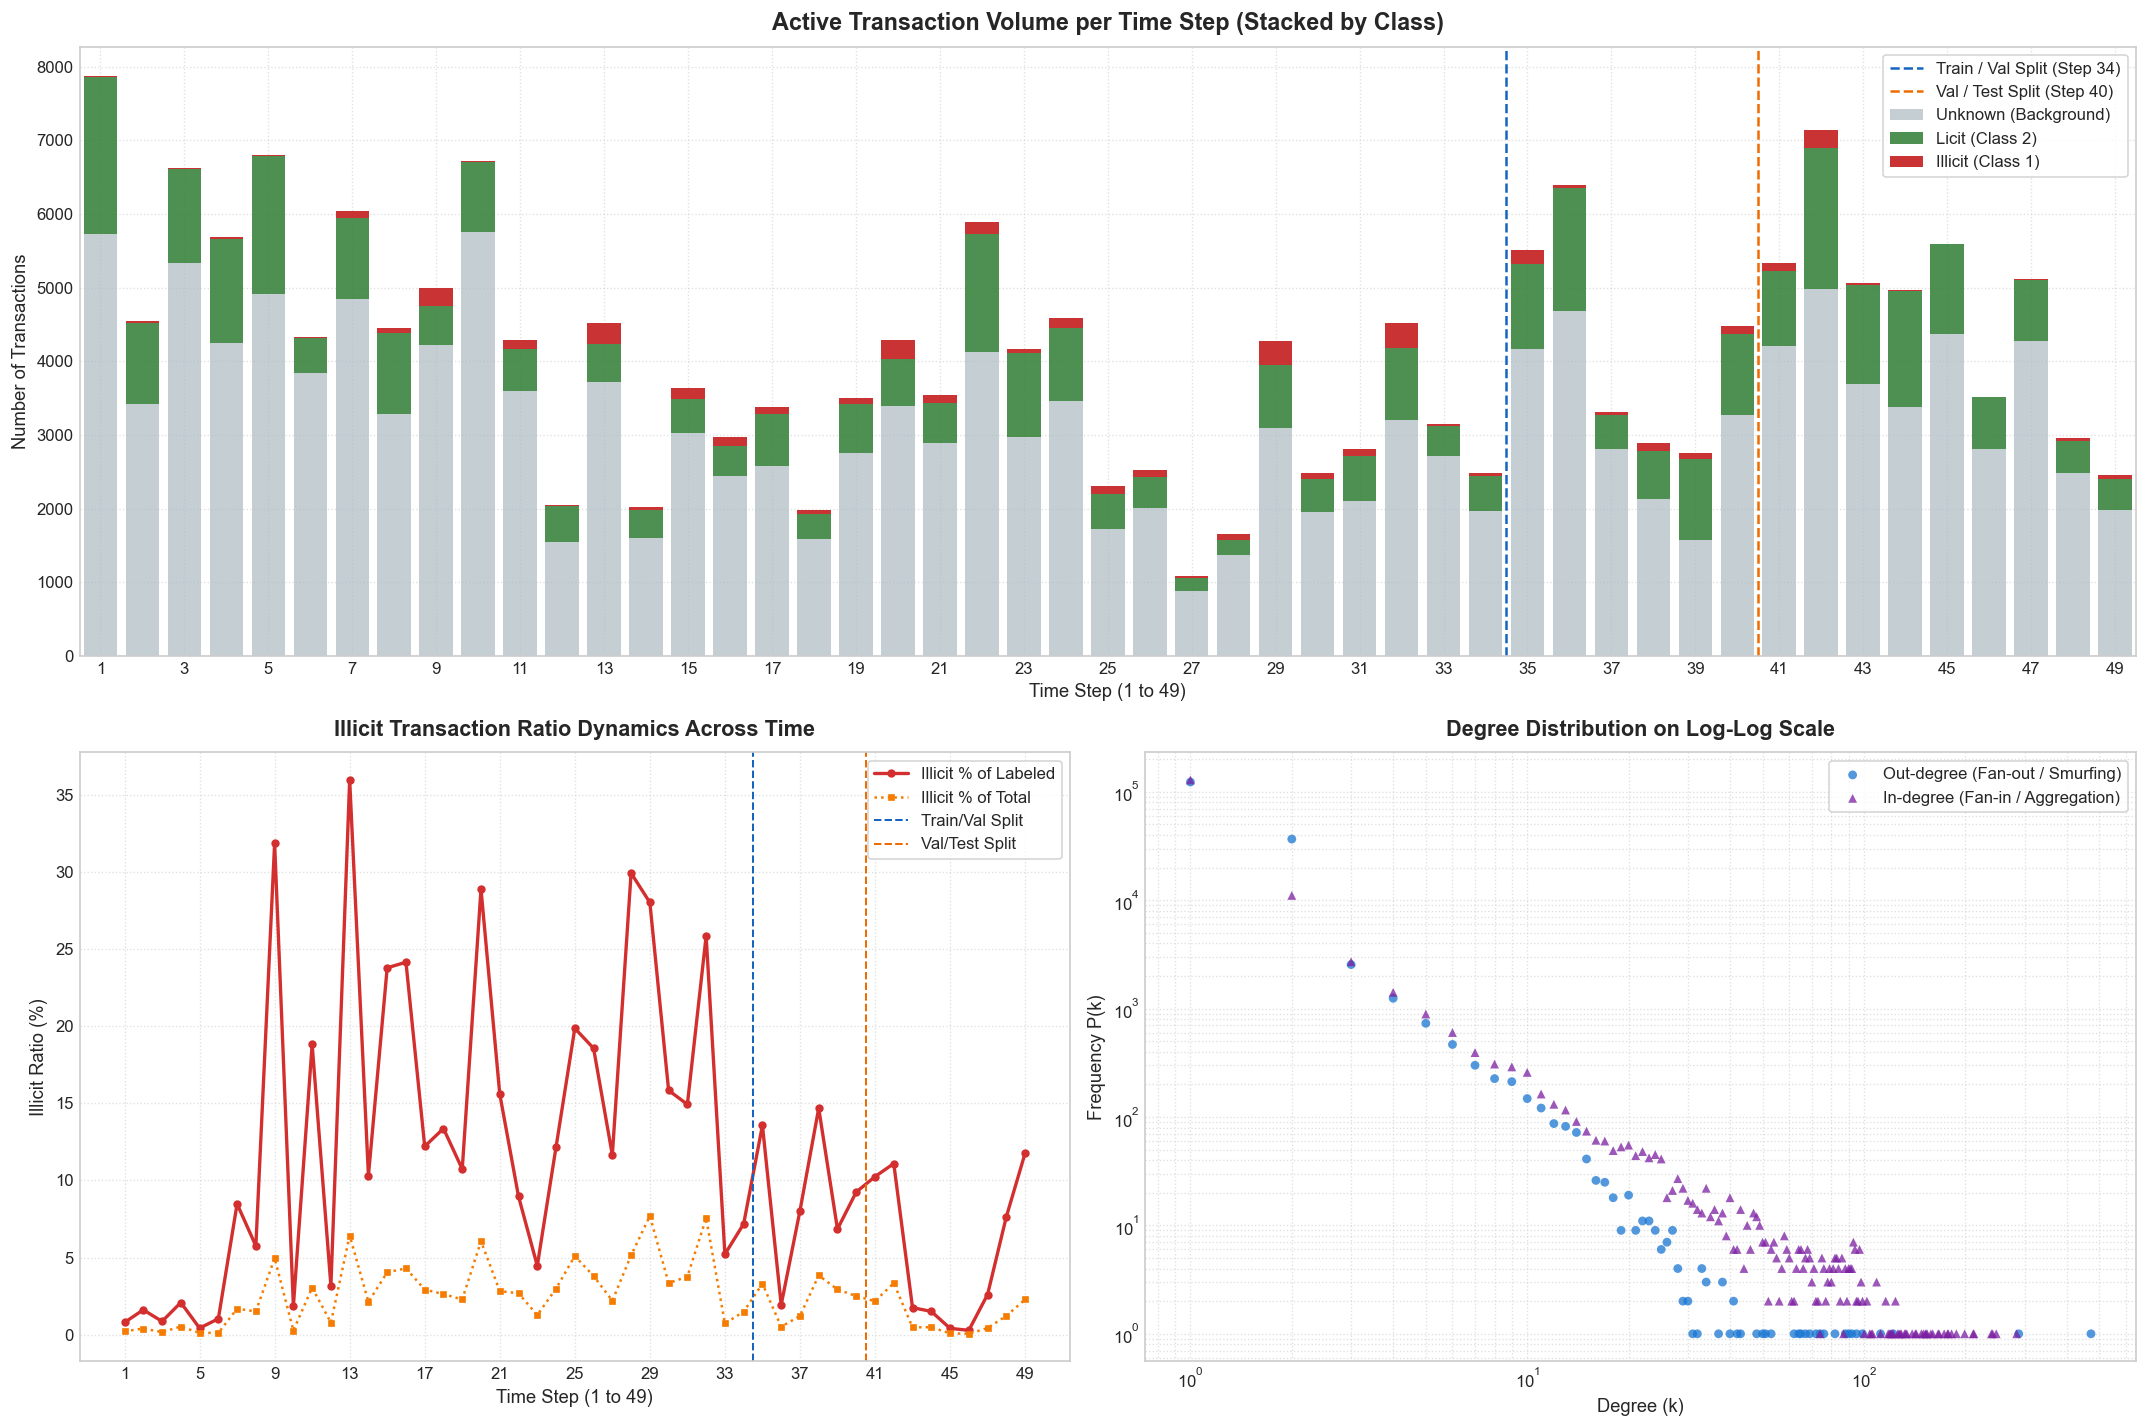

In [5]:
# Merge time step into classes
df_node_meta = pd.merge(df_features[['txId', 'time_step']], df_classes, on='txId')

# Pivot table: count of nodes per time step per class
pivot_counts = df_node_meta.pivot_table(
    index='time_step',
    columns='class',
    values='txId',
    aggfunc='count',
    fill_value=0
)

for col in ['1', '2', 'unknown']:
    if col not in pivot_counts.columns:
        pivot_counts[col] = 0

pivot_counts['total'] = pivot_counts['1'] + pivot_counts['2'] + pivot_counts['unknown']
pivot_counts['labeled'] = pivot_counts['1'] + pivot_counts['2']
pivot_counts['illicit_pct_labeled'] = (pivot_counts['1'] / pivot_counts['labeled'].replace(0, np.nan)) * 100
pivot_counts['illicit_pct_total'] = (pivot_counts['1'] / pivot_counts['total']) * 100

# Compute In-Degree and Out-Degree frequencies
out_degrees = df_edges['txId1'].value_counts()
in_degrees = df_edges['txId2'].value_counts()

# Set up multi-panel plot
fig = plt.figure(figsize=(18, 12))

# Subplot 1: Stacked Bar Chart of Node Count per Time Step
ax1 = fig.add_subplot(2, 2, (1, 2))
t_idx = pivot_counts.index
ax1.bar(t_idx, pivot_counts['unknown'], label='Unknown (Background)', color='#B0BEC5', alpha=0.75)
ax1.bar(t_idx, pivot_counts['2'], bottom=pivot_counts['unknown'], label='Licit (Class 2)', color='#2E7D32', alpha=0.85)
ax1.bar(t_idx, pivot_counts['1'], bottom=pivot_counts['unknown'] + pivot_counts['2'], label='Illicit (Class 1)', color='#C62828', alpha=0.95)
ax1.axvline(x=34.5, color='#1565C0', linestyle='--', linewidth=1.5, label='Train / Val Split (Step 34)')
ax1.axvline(x=40.5, color='#EF6C00', linestyle='--', linewidth=1.5, label='Val / Test Split (Step 40)')
ax1.set_title('Active Transaction Volume per Time Step (Stacked by Class)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Time Step (1 to 49)', fontsize=11)
ax1.set_ylabel('Number of Transactions', fontsize=11)
ax1.set_xlim(0.5, 49.5)
ax1.set_xticks(range(1, 50, 2))
ax1.legend(loc='upper right', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Illicit Ratio Dynamics
ax2 = fig.add_subplot(2, 2, 3)
ax2.plot(t_idx, pivot_counts['illicit_pct_labeled'], marker='o', markersize=4, color='#D32F2F', linewidth=2, label='Illicit % of Labeled')
ax2.plot(t_idx, pivot_counts['illicit_pct_total'], marker='s', markersize=3, color='#F57C00', linewidth=1.5, linestyle=':', label='Illicit % of Total')
ax2.axvline(x=34.5, color='#1565C0', linestyle='--', linewidth=1.2, label='Train/Val Split')
ax2.axvline(x=40.5, color='#EF6C00', linestyle='--', linewidth=1.2, label='Val/Test Split')
ax2.set_title('Illicit Transaction Ratio Dynamics Across Time', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Time Step (1 to 49)', fontsize=11)
ax2.set_ylabel('Illicit Ratio (%)', fontsize=11)
ax2.set_xticks(range(1, 50, 4))
ax2.legend(loc='upper right', frameon=True)
ax2.grid(True, linestyle=':', alpha=0.6)

# Subplot 3: Degree Distribution on Log-Log Scale
ax3 = fig.add_subplot(2, 2, 4)
out_freq = Counter(out_degrees.values)
in_freq = Counter(in_degrees.values)

deg_out_x = sorted(out_freq.keys())
deg_out_y = [out_freq[k] for k in deg_out_x]

deg_in_x = sorted(in_freq.keys())
deg_in_y = [in_freq[k] for k in deg_in_x]

ax3.scatter(deg_out_x, deg_out_y, color='#1976D2', alpha=0.75, s=28, label='Out-degree (Fan-out / Smurfing)', edgecolors='none')
ax3.scatter(deg_in_x, deg_in_y, color='#7B1FA2', alpha=0.75, s=28, marker='^', label='In-degree (Fan-in / Aggregation)', edgecolors='none')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_title('Degree Distribution on Log-Log Scale', fontsize=13, fontweight='bold', pad=10)
ax3.set_xlabel('Degree (k)', fontsize=11)
ax3.set_ylabel('Frequency P(k)', fontsize=11)
ax3.legend(loc='upper right', frameon=True)
ax3.grid(True, which='both', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

---
## 5. Referential Integrity Check
We test whether any transaction ID (`txId`) in the directed edgelist (`txId1` as source or `txId2` as target) is missing from the features file (`elliptic_txs_features.csv`). Missing IDs would produce out-of-bounds indexing errors during graph tensor construction.

In [6]:
features_tx_set = set(df_features['txId'].astype(int))
classes_tx_set = set(df_classes['txId'].astype(int))
edge_src_set = set(df_edges['txId1'].astype(int))
edge_dst_set = set(df_edges['txId2'].astype(int))
edge_nodes_set = edge_src_set.union(edge_dst_set)

missing_from_features = edge_nodes_set - features_tx_set
missing_from_classes = edge_nodes_set - classes_tx_set

print("=" * 65)
print("GRAPH REFERENTIAL INTEGRITY AUDIT")
print("=" * 65)
print(f"Total unique transaction IDs in features : {len(features_tx_set):,}")
print(f"Total unique transaction IDs in classes  : {len(classes_tx_set):,}")
print(f"Unique active nodes in edgelist          : {len(edge_nodes_set):,}")
print(f"  • Source nodes (txId1)                 : {len(edge_src_set):,}")
print(f"  • Target nodes (txId2)                 : {len(edge_dst_set):,}")
print("-" * 65)
print(f"Edgelist txId missing from features file : {len(missing_from_features)}")
print(f"Edgelist txId missing from classes file  : {len(missing_from_classes)}")
print("=" * 65)

if len(missing_from_features) == 0 and len(missing_from_classes) == 0:
    print("✅ REFERENTIAL INTEGRITY CONFIRMED: 0 missing transaction IDs! Every node in the edgelist has full feature and class records.")
else:
    print(f"⚠️ WARNING: Found {len(missing_from_features)} missing transaction IDs!")

# Verification assertion
assert len(missing_from_features) == 0, f"Integrity Failure: {len(missing_from_features)} edge nodes missing from features!"
assert len(missing_from_classes) == 0, f"Integrity Failure: {len(missing_from_classes)} edge nodes missing from classes!"

GRAPH REFERENTIAL INTEGRITY AUDIT
Total unique transaction IDs in features : 203,769
Total unique transaction IDs in classes  : 203,769
Unique active nodes in edgelist          : 203,769
  • Source nodes (txId1)                 : 166,345
  • Target nodes (txId2)                 : 148,447
-----------------------------------------------------------------
Edgelist txId missing from features file : 0
Edgelist txId missing from classes file  : 0
✅ REFERENTIAL INTEGRITY CONFIRMED: 0 missing transaction IDs! Every node in the edgelist has full feature and class records.


---
## 6. Summary of Findings & Implications for TemporalAML

| Finding Dimension | Metric / Observation | Empirical Value | Architectural & Modeling Implication |
| :--- | :--- | :--- | :--- |
| **Dataset Scale** | Total Nodes & Directed Edges | **203,769 nodes**, **234,355 edges** | Fits within GPU memory (e.g. Colab T4 / MPS) using dynamic temporal neighbor sampling ($K=20$). |
| **Referential Integrity** | Edgelist txIds missing in features | **0 missing IDs (100% complete)** | Node-to-tensor index mapping is bijective; no imputation or node-dropping required. |
| **Temporal Granularity** | Discrete Time Steps | **49 intervals** ($t \in [1, 49]$) | Natural inductive evaluation: Train (steps 1–34), Val (steps 35–40), Test (steps 41–49). |
| **Class Imbalance** | Illicit vs. Licit vs. Unknown | **2.23%** Illicit (4,545), **20.62%** Licit (42,019), **77.15%** Unknown (157,205) | Requires class-weighted loss (e.g., pos_weight $pprox 9.24$) and evaluation via PR-AUC / F1-score rather than accuracy. |
| **Temporal Non-Stationarity** | Illicit Ratio Trend Over Time | Substantial drop at step ~43 (darknet seizure) | Demonstrates sudden concept drift, justifying **Learnable Fourier Time Encoding** (O2) to capture dynamic temporal shifts. |
| **Topology & Typologies** | Degree Distribution | **Heavy-tailed / Power-law** ($k_{\max} > 100$) | Structural hub signatures align directly with fan-in / fan-out smurfing and layering typologies (O3). |